In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image



2026-03-06 05:03:01.754792: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772773382.121122      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772773382.225307      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772773383.127415      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772773383.127463      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772773383.127465      55 computation_placer.cc:177] computation placer alr

In [2]:
# ============================================
# 2. DATASET PATHS
# ============================================

TRAIN_DIR ="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train" 
VALID_DIR = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

IMG_SIZE = 224
BATCH_SIZE = 32

# ============================================
# 3. LOAD DATASET
# ============================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Save class names
class_names = train_ds.class_names
print("Total Classes:", len(class_names))

# Prefetch for faster training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)



Found 70295 files belonging to 38 classes.


I0000 00:00:1772773466.029236      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772773466.035203      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17572 files belonging to 38 classes.
Total Classes: 38


In [3]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [4]:
# ============================================
# 4. BUILD MODEL (EfficientNetB0)
# ============================================

def build_model(num_classes):

    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model


model = build_model(len(class_names))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,103,369 (15.65 MB)

 Trainable params: 51,238 (200.15 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [5]:
# ============================================
# 5. CALLBACKS
# ============================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_plant_model.keras",
        save_best_only=True
    ),

    tf.keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    )
]

# ============================================
# 6. PHASE 1 TRAINING
# ============================================

print("Phase 1 Training...")

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

# ============================================
# 7. PHASE 2 FINE TUNING
# ============================================

print("Phase 2 Fine Tuning...")

model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)



Phase 1 Training...
Epoch 1/5


I0000 00:00:1772773484.790421     127 service.cc:152] XLA service 0x7ec2e0114ec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772773484.790455     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772773484.790461     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772773487.309437     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-06 05:04:55.102078: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:04:55.246566: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:04:55.588958: E external/local_xl

2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8225 - loss: 0.6367

2026-03-06 05:07:10.764161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:07:10.906143: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:07:11.241390: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:07:11.383645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:07:12.124569: E external/local_xla/xla/stream_

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8226 - loss: 0.6366

2026-03-06 05:07:58.782526: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:07:58.916725: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:07:59.227193: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:07:59.368160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 05:08:00.084663: E external/local_xla/xla/stream_

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 210s 82ms/step - accuracy: 0.8226 - loss: 0.6364 - val_accuracy: 0.9696 - val_loss: 0.1034 - learning_rate: 0.0010
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 90s 41ms/step - accuracy: 0.9541 - loss: 0.1448 - val_accuracy: 0.9739 - val_loss: 0.0944 - learning_rate: 0.0010
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 89s 41ms/step - accuracy: 0.9574 - loss: 0.1343 - val_accuracy: 0.9783 - val_loss: 0.0736 - learning_rate: 0.0010
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 89s 41ms/step - accuracy: 0.9629 - loss: 0.1159 - val_accuracy: 0.9812 - val_loss: 0.0615 - learning_rate: 0.0010
Phase 2 Fine Tuning...
Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 130s 50ms/step - accuracy: 0.9673 - loss: 0.1006 - val_accuracy: 0.9829 - val_loss: 0.0557 - learning_rate: 1.0000e-05
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 90s 41ms/step - accuracy: 0.9685 - loss: 0.0981 - val_accuracy: 0.9832 - val_loss: 0.0535 - learning_rate: 1.0000e-05
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 89s

Model Saved Successfully!


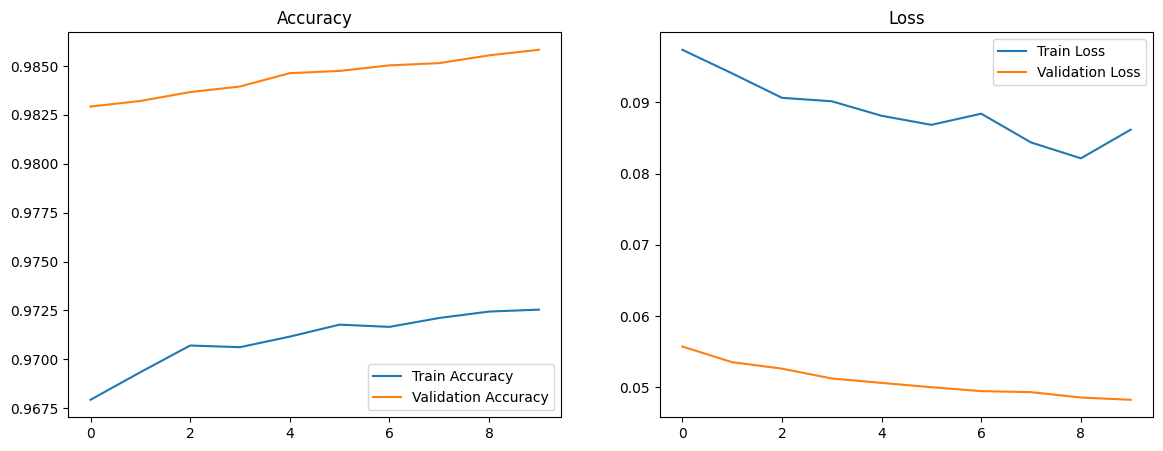

In [6]:
# ============================================
# 8. SAVE MODEL
# ============================================

model.save("final_plant_disease_model.h5")

print("Model Saved Successfully!")

# ============================================
# 9. PLOT TRAINING RESULTS
# ============================================

def plot_results(history):

    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(len(acc))

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.legend()
    plt.title("Accuracy")

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()

plot_results(history)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


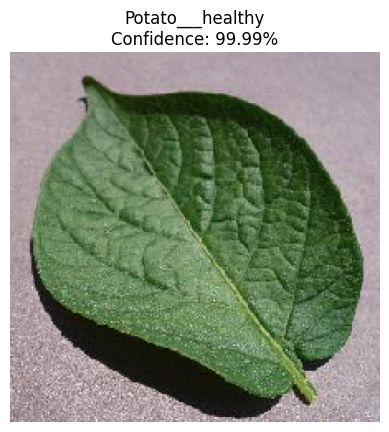

Prediction: Potato___healthy
Confidence: 99.98503


In [9]:
# ============================================
# 10. PREDICT TEST IMAGE
# ============================================

def predict_disease(img_path):

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]

    confidence = prediction[0][predicted_index] * 100

    plt.imshow(img)
    plt.title(f"{predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    print("Prediction:", predicted_class)
    print("Confidence:", confidence)

# ============================================
# 11. TEST IMAGE
# ============================================

test_image = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/PotatoHealthy1.JPG"

predict_disease(test_image)